In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Bezier S-Bend Factory

`bend_s_bezier_factory(kcl)` returns a cached cell function for cubic-bezier
S-bends. Arguments `width`, `height`, and `length` are in **µm**.
`height` is the lateral offset (negative flips the bend); `length` is the
longitudinal extent.

In [2]:
import kfactory as kf
from kfactory.factories.bezier import bend_s_bezier_factory


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


pdk = kf.KCLayout("FACTORIES_BEZIER_DEMO", infos=LAYER)
L = LAYER()

## Basic call

S-bend: bend_s_bezier_CS028523d7_500_H5_L20_NP99_TS0_TS1


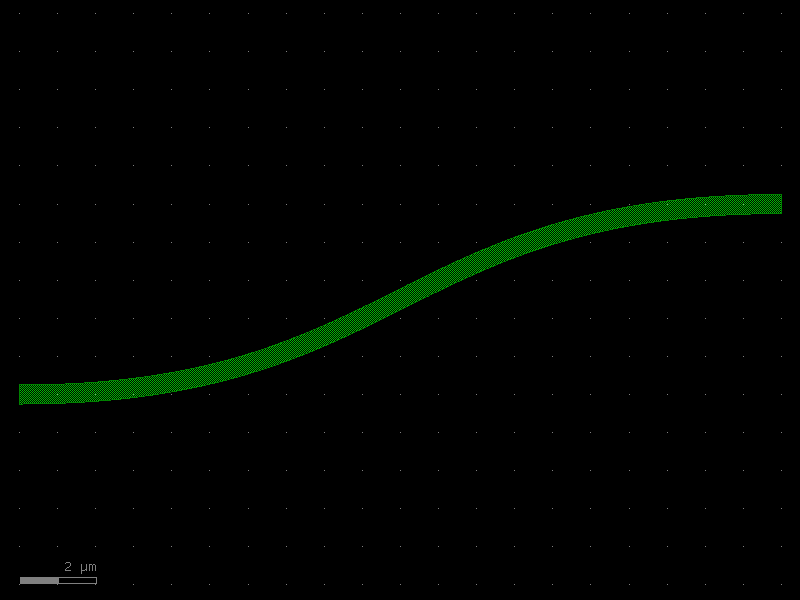

In [3]:
bend_s = bend_s_bezier_factory(pdk)

b = bend_s(width=0.5, height=5.0, length=20.0, layer=L.WG)
print("S-bend:", b.name)
b

## Negative height

A negative `height` flips the offset direction.

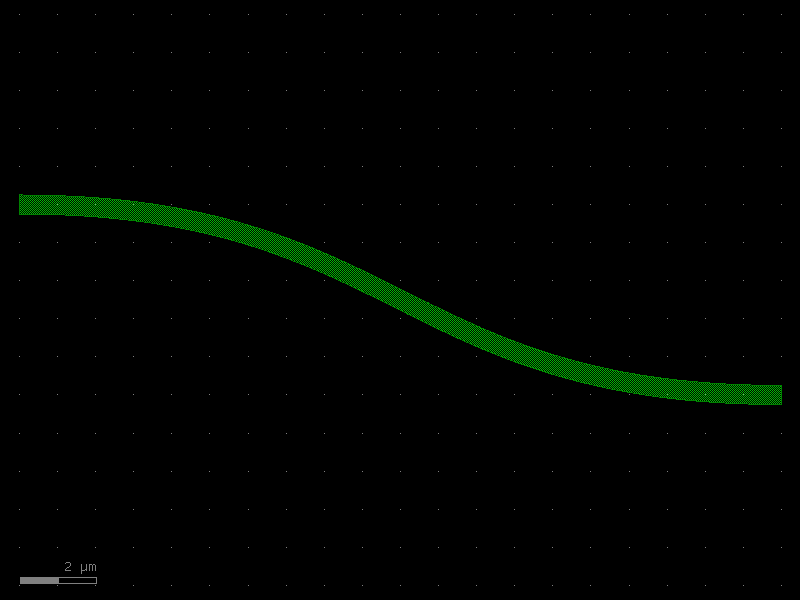

In [4]:
b_flip = bend_s(width=0.5, height=-5.0, length=20.0, layer=L.WG)
b_flip

## Curve resolution

`nb_points` controls the polygon resolution of the bezier backbone (default 99).
Lower values trade smoothness for fewer vertices.

In [5]:
b_lo = bend_s(width=0.5, height=5.0, length=20.0, layer=L.WG, nb_points=20)
b_hi = bend_s(width=0.5, height=5.0, length=20.0, layer=L.WG, nb_points=200)
print("low-res vertices:", b_lo.shapes(L.WG).each().__next__().polygon.num_points())
print("hi-res  vertices:", b_hi.shapes(L.WG).each().__next__().polygon.num_points())

low-res vertices: 40
hi-res  vertices: 362


## Cladding via `LayerEnclosure`

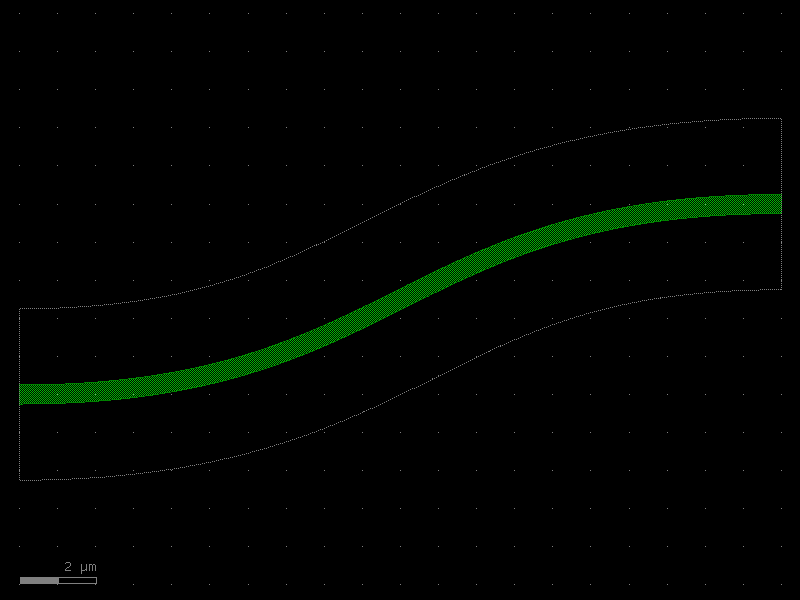

In [6]:
enc = kf.LayerEnclosure(
    sections=[(L.WGCLAD, pdk.to_dbu(2.0))],
    main_layer=L.WG,
    kcl=pdk,
)

b_clad = bend_s(width=0.5, height=5.0, length=20.0, layer=L.WG, enclosure=enc)
b_clad

## Adding metadata

The factory accepts `additional_info` (a dict or callable returning a dict)
that gets merged into `KCell.info`.

In [7]:
bend_s_meta = bend_s_bezier_factory(
    pdk,
    additional_info={"pdk": "FACTORIES_BEZIER_DEMO", "component_type": "bezier_sbend"},
)

b_meta = bend_s_meta(width=0.5, height=5.0, length=20.0, layer=L.WG)
print("cell info:", dict(b_meta.info))

2026-07-15 15:29:04.406 | ERROR    | kfactory.kcell:name:823 - Name conflict in kfactory.kcell::name at line 823
Renaming Unnamed_8 (cell_index=8) to bend_s_bezier_CS028523d7_500_H5_L20_NP99_TS0_TS1 would cause it to be named the same as:
 - bend_s_bezier_CS028523d7_500_H5_L20_NP99_TS0_TS1 (cell_index=0), function_name=_bend_s_bezier, basename=bend_s_bezier


cell info: {'pdk': 'FACTORIES_BEZIER_DEMO', 'component_type': 'bezier_sbend'}


## See Also

| Topic | Where |
|-------|-------|
| Factory overview | [Factories: Overview](overview.py) |
| Euler S-bend (clothoid alternative) | [Factories: Euler](euler.py) |
| All-angle routing with S-bends | [Routing: All-Angle](../../../routing/all_angle.py) |